# Data Preprocessing

## Importing

In [1]:
import pandas as pd
import numpy as np
import joblib
from utils import *
from constants import*

## Loading and Cleaning

In [2]:
df_flights_raw = pd.read_csv("../data/raw/flights_dataset.csv")

In [3]:
df_flights_raw.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [4]:
df_flights = df_flights_raw.copy()

In [5]:
df_flights.drop(DROP_FEATURES, axis=1, inplace=True)

In [6]:
df_flights.head()

,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


## Analyzing

In [7]:
df_flights.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  object 
 1   source_city       300153 non-null  object 
 2   departure_time    300153 non-null  object 
 3   stops             300153 non-null  object 
 4   arrival_time      300153 non-null  object 
 5   destination_city  300153 non-null  object 
 6   class             300153 non-null  object 
 7   duration          300153 non-null  float64
 8   days_left         300153 non-null  int64  
 9   price             300153 non-null  int64  
dtypes: float64(1), int64(2), object(7)
memory usage: 22.9+ MB


In [8]:
df_flights.describe()

,duration,days_left,price
count,300153.000000,300153.000000,300153.000000
mean,12.221021,26.004751,20889.660523
std,7.191997,13.561004,22697.767366
min,0.830000,1.000000,1105.000000
25%,6.830000,15.000000,4783.000000
50%,11.250000,26.000000,7425.000000
75%,16.170000,38.000000,42521.000000
max,49.830000,49.000000,123071.000000


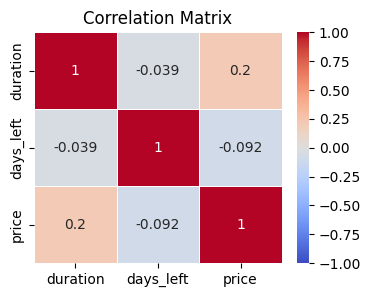

In [9]:
graphing_correlation_matrix(dataframe=df_flights[NUMERICAL_FEATURES+[TARGET]])

array([[<Axes: title={'center': 'duration'}>,
        <Axes: title={'center': 'days_left'}>],
       [<Axes: title={'center': 'price'}>, <Axes: >]], dtype=object)

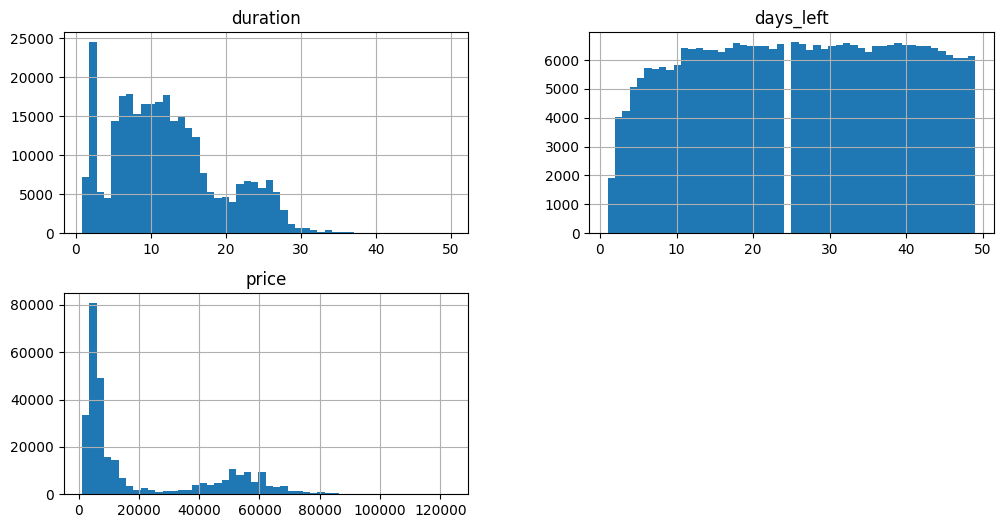

In [10]:
df_flights.hist(bins=50, figsize=(12,6))

In [11]:
object_features_report(df_flights)

********************Unique Counts********************
airline             6
source_city         6
departure_time      6
stops               3
arrival_time        6
destination_city    6
class               2
dtype: int64

********************Unique Values********************
Feature 'airline': ['SpiceJet' 'AirAsia' 'Vistara' 'GO_FIRST' 'Indigo' 'Air_India']
Feature 'source_city': ['Delhi' 'Mumbai' 'Bangalore' 'Kolkata' 'Hyderabad' 'Chennai']
Feature 'departure_time': ['Evening' 'Early_Morning' 'Morning' 'Afternoon' 'Night' 'Late_Night']
Feature 'stops': ['zero' 'one' 'two_or_more']
Feature 'arrival_time': ['Night' 'Morning' 'Early_Morning' 'Afternoon' 'Evening' 'Late_Night']
Feature 'destination_city': ['Mumbai' 'Bangalore' 'Kolkata' 'Hyderabad' 'Chennai' 'Delhi']
Feature 'class': ['Economy' 'Business']

********************Value Counts********************
Feature 'airline' values: airline
Vistara      127859
Air_India     80892
Indigo        43120
GO_FIRST      23173
AirAsia       160

## Splitting

In [12]:
X_train, X_test, y_train, y_test = split_dataset(target_feature=TARGET, dataframe=df_flights,
                                                    test_percentage=TEST_PERCENTAGE, seed=SEED, stratify_feature=STRATIFY_FEATURE)

X_train: (240122, 9)
y_train: (240122,)
X_test: (60031, 9)
y_test: (60031,)


## Feature Engineering

### Nominal Encoding

In [13]:
X_train, X_test = encoding_nominal_features(features_train=X_train, features_test=X_test, nominal_features=NOMINAL_FEATURES)

One Hot Encoding with handle_unknown='ignore' and drop='first' done.


### Ordinal Encoding

In [14]:
categories_list = [CUSTOM_ORDER[col] for col in ORDINAL_FEATURES]
X_train, X_test = encoding_ordinal_features(features_train=X_train, features_test=X_test, ordinal_features=ORDINAL_FEATURES, categories_list=categories_list)

Ordinal Encoding with handle_unknown='use_encoded_value' and unknown_value=-1 done.


### Scaling

In [15]:
X_train, X_test = scaling_numerical_features(features_train=X_train, features_test=X_test, features_to_scale=NUMERICAL_FEATURES+ORDINAL_FEATURES)

Min Max Scaling done.


In [16]:
X_train.head()

,departure_time,stops,arrival_time,class,duration,days_left,airline_Air_India,airline_GO_FIRST,airline_Indigo,airline_SpiceJet,...,source_city_Chennai,source_city_Delhi,source_city_Hyderabad,source_city_Kolkata,source_city_Mumbai,destination_city_Chennai,destination_city_Delhi,destination_city_Hyderabad,destination_city_Kolkata,destination_city_Mumbai
0,0.0,0.5,0.8,1.0,0.339301,0.270833,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
1,0.4,0.5,0.2,0.0,0.385550,0.645833,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,0.2,0.0,0.4,0.0,0.014280,0.895833,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.5,0.2,0.0,0.547101,0.375000,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,0.5,0.4,0.0,0.184783,0.250000,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [17]:
X_test.head()

,departure_time,stops,arrival_time,class,duration,days_left,airline_Air_India,airline_GO_FIRST,airline_Indigo,airline_SpiceJet,...,source_city_Chennai,source_city_Delhi,source_city_Hyderabad,source_city_Kolkata,source_city_Mumbai,destination_city_Chennai,destination_city_Delhi,destination_city_Hyderabad,destination_city_Kolkata,destination_city_Mumbai
0,0.6,0.5,0.2,0.0,0.330350,0.687500,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.2,0.5,0.6,0.0,0.115516,0.895833,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.6,0.5,0.8,1.0,0.135124,0.916667,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,0.4,0.5,0.8,0.0,0.154518,0.312500,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,0.6,1.0,0.8,0.0,0.586104,0.395833,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


## Linearity

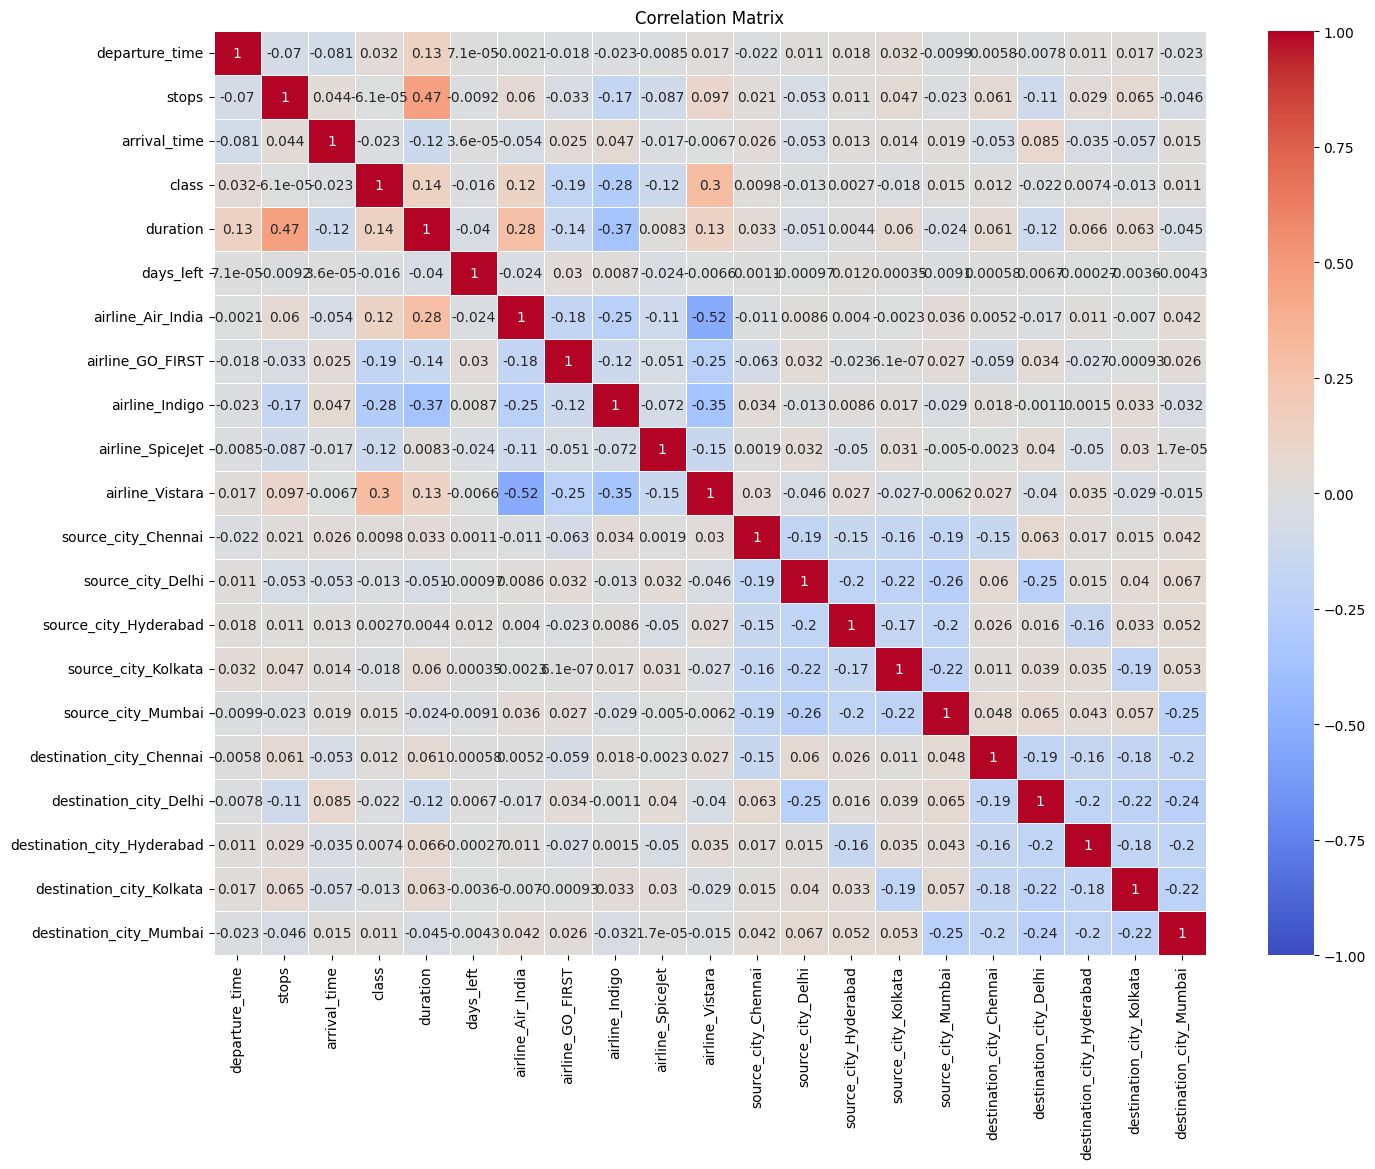

In [18]:
graphing_correlation_matrix(dataframe=X_train, zoom=4)

## Saving artifacts

In [19]:
data = {
    "X_train": X_train,
    "X_test": X_test,
    "y_train": y_train,
    "y_test": y_test
}
joblib.dump(data, "../data/processed/train_test_data.joblib")

['../data/processed/train_test_data.joblib']